# Phishing Detection Classification Model

## 1. Importing Libraries and Modules

In [4]:
!pip install numpy pandas scikit-learn matplotlib imblearn #makes sure key python libraries are installed

In [5]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler #for sample weight balancing if needed
from sklearn.ensemble import RandomForestClassifier #for configuring the RF algorithm
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, f1_score, recall_score #for model evaluation
import matplotlib.pyplot as plt #used for metrics visualisation
import seaborn as sns #can also be useful for visualisation




## 2. Loading the Dataset

In [6]:
file_path = "email_phishing_data.csv" #chosen dataset must first be uploaded to colab session Files

df = pd.read_csv(file_path) #loads the dataset
print(df.head()) #to check the dataset has loaded properly

   num_words  num_unique_words  num_stopwords  num_links  num_unique_domains  \
0        140                94             52          0                   0   
1          5                 5              1          0                   0   
2         34                32             15          0                   0   
3          6                 6              2          0                   0   
4          9                 9              2          0                   0   

   num_email_addresses  num_spelling_errors  num_urgent_keywords  label  
0                    0                    0                    0      0  
1                    0                    0                    0      0  
2                    0                    0                    0      0  
3                    0                    0                    0      0  
4                    0                    0                    0      0  


## 3. Preprocessing the Dataset

In [7]:
df = df.dropna() #removes any empty rows
df = df.drop_duplicates() #to remove any duplicate samples

duplicate_rows = df.duplicated().sum() #calculate total number of exact duplicate rows remaining, if any
print("Duplicate rows identified: ", duplicate_rows) #displays result of exact duplicate total

print("Total number of sample rows: ", len(df)) #to check total number of sample rows remaining after preprocessing

Duplicate rows identified:  0
Total number of sample rows:  205052


## 4. Splitting the Data (Training and Testing)

In [8]:
X = df.drop('label', axis=1) #specifies sample label column as the target
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y) #standard split values, can be changed later if needed
#stratify function keeps the same split ratio, for phishing vs non-phishing, as the source dataset



## 5. Random Forest Implementation and Configuration

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = "balanced") #parameters for RF algorithm, consider adding class_weight if imbalance is too much

rf.fit(X_train, y_train) #applies RF classifier to the split training data variables

RandomForestClassifier(class_weight='balanced', random_state=42)

## 6. Model Prediction and Evaluation

In [10]:
y_pred = rf.predict(X_test)

#predicted probabilities of positive phishing classification
y_prob = rf.predict_proba(X_test)[:,1] #makes label predictions for each sample in X_test, to later be compared with the real labels in y_test


#for ROC (Receiver Operating Characteristic) curve
falsePositiveRate, truePositiveRate, thresholds = roc_curve(y_test, y_prob)

#for AUC (Area Under Curve),
roc_auc = auc(falsePositiveRate, truePositiveRate)

#section for evaluating model metrics

mPrecision = precision_score(y_test, y_pred) #precision metric is stored in mPrecision once calculated
mRecall = recall_score(y_test, y_pred)
mf1_Scoring = f1_score(y_test, y_pred) #f1 score can help with balancing precision and recall

mReport = classification_report(y_test, y_pred, digits = 2) #presents metrics rounded to 2 decimal places, easier readability

mConfusionTrix = confusion_matrix(y_test, y_pred)

# TN = Non-phishing correctly predicted, FP = Non-phishing wrongly predicted
# FN = Phishing wrongly predicted, TP = Phishing correctly predicted

# The two comments above describe what the confusion matrix report values mean


print("Model Precision: ", mPrecision) #prints precision result stored in mPrecision variable
print("Model Recall: ", mRecall)
print("Model F1 Score: ", mf1_Scoring)

print("\nFull Classification Report: \n", mReport)

print("\nConfusion Matrix Report: \n", mConfusionTrix) #print the matrix report metrics

print("\nArea Under Curve Analysis: ", roc_auc)


Model Precision:  0.5162241887905604
Model Recall:  0.14391447368421054
Model F1 Score:  0.22508038585209003

Full Classification Report: 
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     39795
           1       0.52      0.14      0.23      1216

    accuracy                           0.97     41011
   macro avg       0.75      0.57      0.61     41011
weighted avg       0.96      0.97      0.96     41011


Confusion Matrix Report: 
 [[39631   164]
 [ 1041   175]]

Area Under Curve Analysis:  0.808442682811911


## 7. Metrics Visualisation

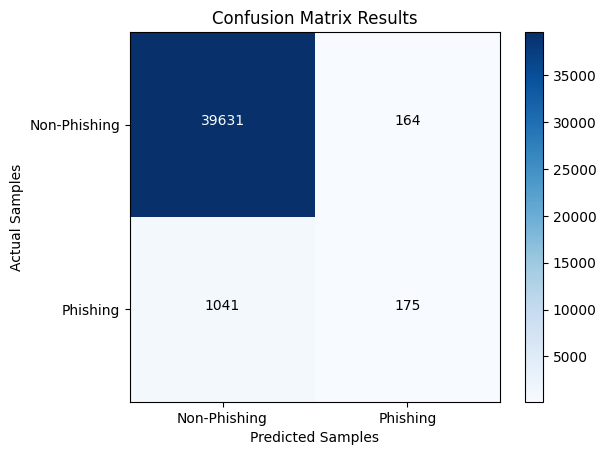

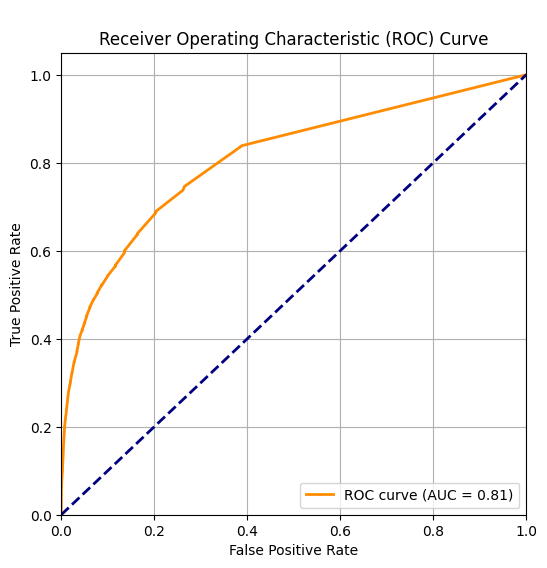

In [11]:
plt.imshow(mConfusionTrix, interpolation='nearest', cmap = plt.cm.Blues)
#cmap specifies the blues colour mapping option in matplotlib, can be changed to other colour options
#interpolation refers to how the colours for each matrix cell blend together, in this case they are solid with no blending


plt.title("Confusion Matrix Results") #specifies the top title above the colourmap
plt.colorbar() #adds a colour gradient to the left of the graph, for better understanding of each shade

#For confusion matrix labels
classifications = ['Non-Phishing', 'Phishing']
indexLabels = np.arange(len(classifications))
#Index Labels are the lines and corresponding labels for each array index
plt.xticks(indexLabels, classifications)
plt.yticks(indexLabels, classifications)


#For confusion matrix cell text
#To improve readability, font colour will change between white/black depending on matrix background colour gradient
pivotPoint = mConfusionTrix.max() / 2 #pivot point is when the matrix cell sample number reaches >50% of total samples
for i in range(mConfusionTrix.shape[0]):
    for j in range(mConfusionTrix.shape[1]):
        plt.text(j, i, mConfusionTrix[i, j],
                 horizontalalignment = "center",
                 color = "white" if mConfusionTrix[i, j] > pivotPoint else "black")


#Labels for the X and Y axis
plt.ylabel('Actual Samples')
plt.xlabel('Predicted Samples')

#command to visualise the results
plt.show()


#Visualisation for ROC-curve

plt.figure(figsize = (6,6))
plt.plot(falsePositiveRate, truePositiveRate, color = 'darkorange', lw = 2, label = f'ROC curve (AUC = {roc_auc:.2f})') #label parameters for the graph legend
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')

#limits for graph axis, keeps plotting on the graph
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('\nReceiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right')
plt.grid(True)
plt.show()



